<a href="https://colab.research.google.com/github/Ben-Tait/Machine_Learning_Projects/blob/main/Ice_Cream_Sales_%E2%80%94_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Create the Dataset

In [2]:
data = {
    'Temperature': [5, 8, 10, 12, 15, 18, 20, 22, 25, 28,
                    30, 32, 35, 36, 38, 40, 42, 43, 45, 48],
    'IceCreamSales': [210, 280, 320, 380, 450, 550, 640, 720, 850, 970,
                      1050, 1100, 1150, 1160, 1155, 1120, 1060, 1020, 950, 860]
}

dataset = pd.DataFrame(data)
print(dataset)

    Temperature  IceCreamSales
0             5            210
1             8            280
2            10            320
3            12            380
4            15            450
5            18            550
6            20            640
7            22            720
8            25            850
9            28            970
10           30           1050
11           32           1100
12           35           1150
13           36           1160
14           38           1155
15           40           1120
16           42           1060
17           43           1020
18           45            950
19           48            860


### Split into x and y

In [4]:
x = dataset.iloc[:, :1].values
y = dataset.iloc[:, 1].values
print(x)
print(y)

[[ 5]
 [ 8]
 [10]
 [12]
 [15]
 [18]
 [20]
 [22]
 [25]
 [28]
 [30]
 [32]
 [35]
 [36]
 [38]
 [40]
 [42]
 [43]
 [45]
 [48]]
[ 210  280  320  380  450  550  640  720  850  970 1050 1100 1150 1160
 1155 1120 1060 1020  950  860]


### Reshape y

In [11]:
y = y.reshape(len(y), 1)
print(y)

[[-1.84259822]
 [-1.6238922 ]
 [-1.49891733]
 [-1.31145503]
 [-1.09274901]
 [-0.78031184]
 [-0.49911838]
 [-0.24916864]
 [ 0.15699968]
 [ 0.53192429]
 [ 0.78187402]
 [ 0.93809261]
 [ 1.09431119]
 [ 1.12555491]
 [ 1.10993305]
 [ 1.00058004]
 [ 0.81311774]
 [ 0.68814287]
 [ 0.46943685]
 [ 0.1882434 ]]


### Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x = sc_x.fit_transform(x)
y = sc_y.fit_transform(y)
print(x)
print(y)

[[-1.74083233]
 [-1.50974839]
 [-1.35569244]
 [-1.20163648]
 [-0.97055254]
 [-0.7394686 ]
 [-0.58541264]
 [-0.43135668]
 [-0.20027275]
 [ 0.03081119]
 [ 0.18486715]
 [ 0.33892311]
 [ 0.57000705]
 [ 0.64703503]
 [ 0.80109099]
 [ 0.95514694]
 [ 1.1092029 ]
 [ 1.18623088]
 [ 1.34028684]
 [ 1.57137078]]
[[-1.84259822]
 [-1.6238922 ]
 [-1.49891733]
 [-1.31145503]
 [-1.09274901]
 [-0.78031184]
 [-0.49911838]
 [-0.24916864]
 [ 0.15699968]
 [ 0.53192429]
 [ 0.78187402]
 [ 0.93809261]
 [ 1.09431119]
 [ 1.12555491]
 [ 1.10993305]
 [ 1.00058004]
 [ 0.81311774]
 [ 0.68814287]
 [ 0.46943685]
 [ 0.1882434 ]]


### Train the SVR Model

In [10]:
from sklearn.svm import SVR
regressor = SVR(kernel= "rbf")
regressor.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

### Make a Prediction

In [12]:
temp = [[33]]

prediction = sc_y.inverse_transform(
    regressor.predict(sc_x.transform(temp)).reshape(-1, 1)
)

print(f"Predicted ice cream sales at {temp[0][0]}°C: {prediction[0][0]:.0f} units")

Predicted ice cream sales at 33°C: 1095 units


### Visualise the Results

/tmp/ipykernel_363/404607381.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid = np.arange(min(sc_x.inverse_transform(x)), max(sc_x.inverse_transform(x)), 0.1)


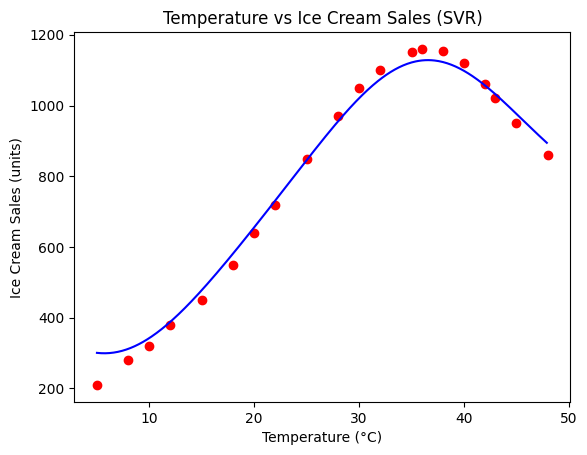

In [20]:
x_grid = np.arange(min(sc_x.inverse_transform(x)), max(sc_x.inverse_transform(x)), 0.1)
x_grid = x_grid.reshape(len(x_grid), 1)

plt.scatter(sc_x.inverse_transform(x), sc_y.inverse_transform(y), color='red')
plt.plot(x_grid, sc_y.inverse_transform(regressor.predict(sc_x.transform(x_grid)).reshape(-1, 1)), color='blue')
plt.title('Temperature vs Ice Cream Sales (SVR)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.show()